# 04 Innovations

This notebook fits classical forecast innovation models to VAR residuals.

The innovation models considered here are:

- Gaussian innovations
- Bootstrap innovations
- Student-t innovations

These are forecast innovation assumptions, not true DGP innovations. The purpose is to compare how different residual-based innovation models approximate the empirical residual distribution before introducing diffusion-based innovation modeling.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from src.utils.seeds import set_seed
from src.utils.logging_utils import make_run_dir, save_metrics_json, save_table_csv
from src.data.loaders import load_npz, save_npz

from src.innovations.gaussian import (
    fit_gaussian_innovation_model,
    sample_from_gaussian_model,
)

from src.innovations.bootstrap import (
    fit_bootstrap_innovation_model,
    sample_from_bootstrap_model,
)

from src.innovations.student_t import (
    fit_student_t_innovation_model,
    sample_from_student_t_model,
)

from src.innovations.diagnostics import (
    summarize_innovations,
    flatten_sampled_innovations,
)

set_seed(123)

dgp_names = [
    "gaussian",
    "student_t",
    "mixture",
    "heteroskedastic",
]

innovation_model_names = [
    "gaussian",
    "bootstrap",
    "student_t",
]

n_paths = 1000
horizon = 40
student_t_df = 5.0

resid_dir = ROOT / "results" / "residuals" / "03_residuals"
innovation_dir = ROOT / "results" / "innovations" / "04_innovations"
table_dir = ROOT / "results" / "tables" / "04_innovations"

innovation_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

In [2]:
residual_store = {}

for name in dgp_names:
    path = resid_dir / f"{name}_var_residuals.npz"
    data = load_npz(path)

    residuals = data["residuals"]
    residual_store[name] = residuals

    print(name, residuals.shape)

gaussian (299, 3)
student_t (299, 3)
mixture (299, 3)
heteroskedastic (299, 3)


## Fit Classical Innovation Models

Each innovation model is fitted to the VAR residuals from each DGP.

The Gaussian model estimates a residual mean and covariance matrix. The bootstrap model resamples empirical residual vectors. The Student-t model uses a heavy-tailed parametric approximation with fixed degrees of freedom.

In [3]:
innovation_models = {}
sampled_innovations = {}

for dgp_name, residuals in residual_store.items():
    gaussian_model = fit_gaussian_innovation_model(residuals)
    bootstrap_model = fit_bootstrap_innovation_model(residuals)
    student_t_model = fit_student_t_innovation_model(
        residuals,
        df=student_t_df,
    )

    innovation_models[dgp_name] = {
        "gaussian": gaussian_model,
        "bootstrap": bootstrap_model,
        "student_t": student_t_model,
    }

    sampled_innovations[dgp_name] = {
        "gaussian": sample_from_gaussian_model(
            gaussian_model,
            n_paths=n_paths,
            horizon=horizon,
            seed=101,
        ),
        "bootstrap": sample_from_bootstrap_model(
            bootstrap_model,
            n_paths=n_paths,
            horizon=horizon,
            seed=102,
        ),
        "student_t": sample_from_student_t_model(
            student_t_model,
            n_paths=n_paths,
            horizon=horizon,
            seed=103,
        ),
    }

    print(dgp_name)
    for model_name, samples in sampled_innovations[dgp_name].items():
        print(" ", model_name, samples.shape)

gaussian
  gaussian (1000, 40, 3)
  bootstrap (1000, 40, 3)
  student_t (1000, 40, 3)
student_t
  gaussian (1000, 40, 3)
  bootstrap (1000, 40, 3)
  student_t (1000, 40, 3)
mixture
  gaussian (1000, 40, 3)
  bootstrap (1000, 40, 3)
  student_t (1000, 40, 3)
heteroskedastic
  gaussian (1000, 40, 3)
  bootstrap (1000, 40, 3)
  student_t (1000, 40, 3)


/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: divide by zero encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: overflow encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: invalid value encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/student_t.py:49: RuntimeWarning: divide by zero encountered in matmul
  z = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/student_t.py:49: RuntimeWarning: overflow encountered in matmul
  z = rng.multivariate_normal(
/

In [4]:
# save output
for dgp_name, model_samples in sampled_innovations.items():
    for model_name, samples in model_samples.items():
        save_npz(
            innovation_dir / f"{dgp_name}_{model_name}_innovations.npz",
            innovations=samples,
        )

print("Saved innovation samples to:", innovation_dir)

Saved innovation samples to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/innovations/04_innovations


In [5]:
diagnostic_rows = []

for dgp_name, model_samples in sampled_innovations.items():
    residuals = residual_store[dgp_name]
    residual_diag = summarize_innovations(residuals)

    for j in range(residuals.shape[1]):
        diagnostic_rows.append({
            "dgp": dgp_name,
            "innovation_model": "empirical_residuals",
            "series": j + 1,
            "mean": residual_diag["mean"][j],
            "std": residual_diag["std"][j],
            "skewness": residual_diag["skewness"][j],
            "kurtosis": residual_diag["kurtosis"][j],
            "excess_kurtosis": residual_diag["excess_kurtosis"][j],
            "jb_pvalue": residual_diag["jarque_bera_pvalue"][j],
        })

    for model_name, samples in model_samples.items():
        flat_samples = flatten_sampled_innovations(samples)
        diag = summarize_innovations(flat_samples)

        for j in range(flat_samples.shape[1]):
            diagnostic_rows.append({
                "dgp": dgp_name,
                "innovation_model": model_name,
                "series": j + 1,
                "mean": diag["mean"][j],
                "std": diag["std"][j],
                "skewness": diag["skewness"][j],
                "kurtosis": diag["kurtosis"][j],
                "excess_kurtosis": diag["excess_kurtosis"][j],
                "jb_pvalue": diag["jarque_bera_pvalue"][j],
            })

innovation_diagnostics_df = pd.DataFrame(diagnostic_rows)
innovation_diagnostics_df

,dgp,innovation_model,series,mean,std,skewness,kurtosis,excess_kurtosis,jb_pvalue
0,gaussian,empirical_residuals,1,-1.930823e-17,1.018841,-0.213540,3.365426,0.365426,1.584815e-01
1,gaussian,empirical_residuals,2,-1.708035e-17,0.979803,0.245287,3.304344,0.304344,1.394637e-01
2,gaussian,empirical_residuals,3,9.654113e-18,1.032848,0.041653,2.989496,-0.010504,9.526328e-01
3,gaussian,gaussian,1,8.308914e-03,1.020998,0.008430,2.941591,-0.058409,4.533248e-02
4,gaussian,gaussian,2,1.523854e-04,0.981689,-0.002158,2.987269,-0.012731,8.574857e-01
5,gaussian,gaussian,3,1.040993e-03,1.035491,-0.002841,2.976919,-0.023081,6.209370e-01
6,gaussian,bootstrap,1,8.185274e-03,1.016720,-0.201126,3.273357,0.273357,2.737232e-86
7,gaussian,bootstrap,2,6.193248e-04,0.977655,0.232561,3.248780,0.248780,2.205307e-101
8,gaussian,bootstrap,3,4.105208e-03,1.035057,0.014477,2.958932,-0.041068,1.207545e-01
9,gaussian,student_t,1,-1.677528e-04,1.031811,0.194043,10.498845,7.498845,0.000000e+00


In [6]:
summary_df = innovation_diagnostics_df.groupby(
    ["dgp", "innovation_model"]
)[
    [
        "skewness",
        "kurtosis",
        "excess_kurtosis",
        "jb_pvalue",
    ]
].mean()

summary_df

skewness  kurtosis  excess_kurtosis  \
dgp             innovation_model                                           
gaussian        bootstrap            0.015304  3.160356         0.160356   
                empirical_residuals  0.024466  3.219755         0.219755   
                gaussian             0.001144  2.968593        -0.031407   
                student_t            0.043218  8.473939         5.473939   
heteroskedastic bootstrap           -0.085464  5.631928         2.631928   
                empirical_residuals -0.091313  5.683345         2.683345   
                gaussian            -0.009224  2.978645        -0.021355   
                student_t           -0.149026  9.588064         6.588064   
mixture         bootstrap           -0.062053  6.286551         3.286551   
                empirical_residuals -0.056410  6.421472         3.421472   
                gaussian            -0.000063  2.974284        -0.025716   
                student_t            0.052653  8.503268         5.503268   
student_t       bootstrap           -0.235132  8.428983         5.428983   
                empirical_residuals -0.214752  8.428872         5.428872   
                gaussian             0.001266  2.968934        -0.031066   
                student_t            0.020856  8.102789         5.102789   

                                        jb_pvalue  
dgp             innovation_model                   
gaussian        bootstrap            4.025151e-02  
                empirical_residuals  4.168593e-01  
                gaussian             5.079184e-01  
                student_t            0.000000e+00  
heteroskedastic bootstrap            0.000000e+00  
                empirical_residuals  6.997397e-20  
                gaussian             3.227402e-01  
                student_t            0.000000e+00  
mixture         bootstrap            0.000000e+00  
                empirical_residuals  1.579140e-12  
                gaussian             3.854318e-01  
                student_t            0.000000e+00  
student_t       bootstrap            0.000000e+00  
                empirical_residuals  1.304477e-57  
                gaussian             4.285769e-01  
                student_t            0.000000e+00

In [7]:
# save output
save_table_csv(
    innovation_diagnostics_df,
    table_dir / "innovation_diagnostics_by_series.csv",
)

save_table_csv(
    summary_df.reset_index(),
    table_dir / "innovation_diagnostics_summary.csv",
)

print("Saved diagnostics to:", table_dir)

Saved diagnostics to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/tables/04_innovations


In [8]:
def plot_innovation_comparison(dgp_name, variable=0):
    residuals = residual_store[dgp_name][:, variable]

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(9, 9),
        sharex=False,
    )

    axes[0].hist(
        residuals,
        bins=35,
        density=True,
        alpha=0.65,
    )
    axes[0].set_title(f"{dgp_name}: empirical residuals")

    for ax, model_name in zip(
        axes[1:],
        ["gaussian", "bootstrap", "student_t"],
    ):
        samples = flatten_sampled_innovations(
            sampled_innovations[dgp_name][model_name]
        )[:, variable]

        ax.hist(
            samples,
            bins=35,
            density=True,
            alpha=0.65,
        )

        ax.set_title(f"{dgp_name}: {model_name} innovation samples")

    plt.tight_layout()
    plt.show()

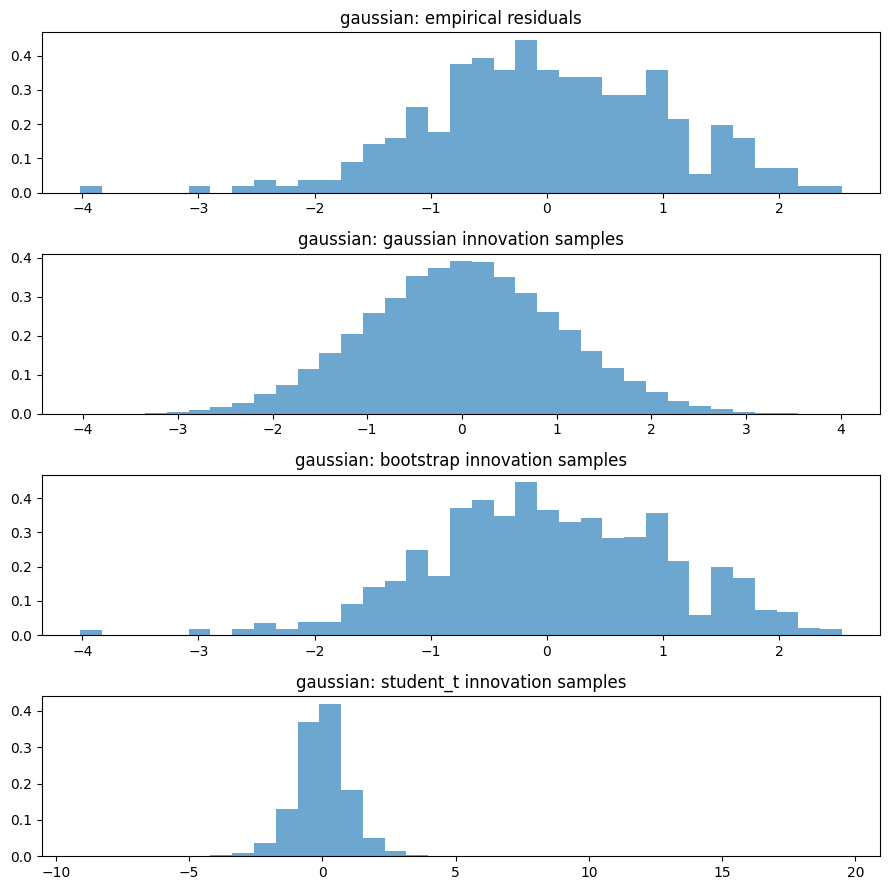

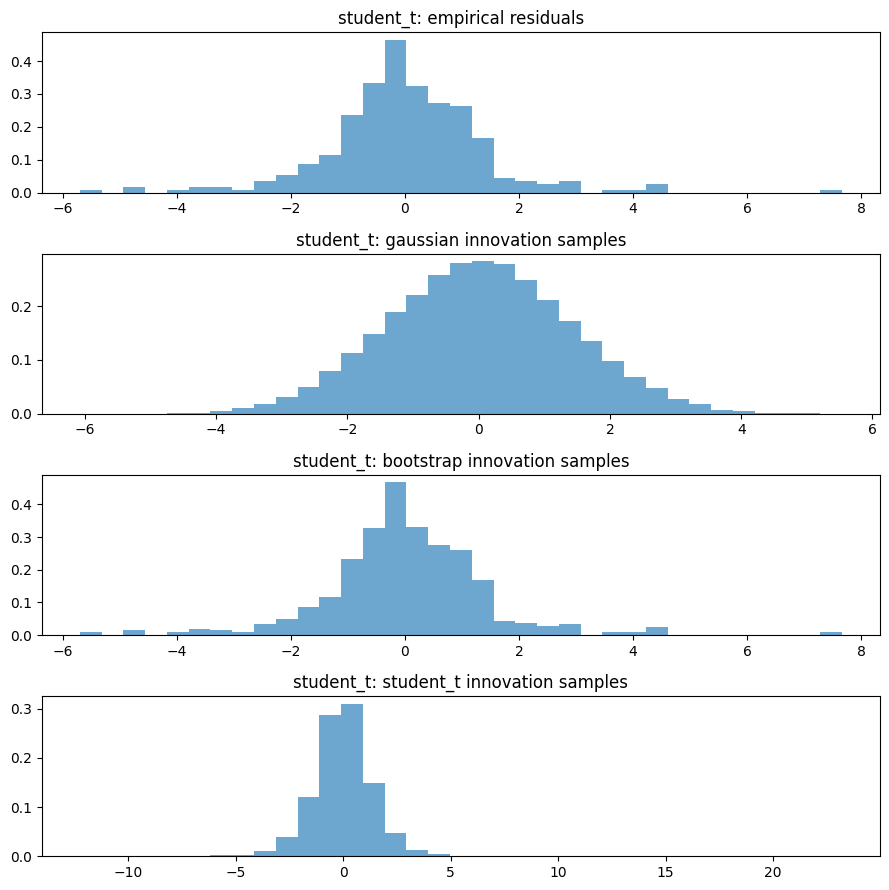

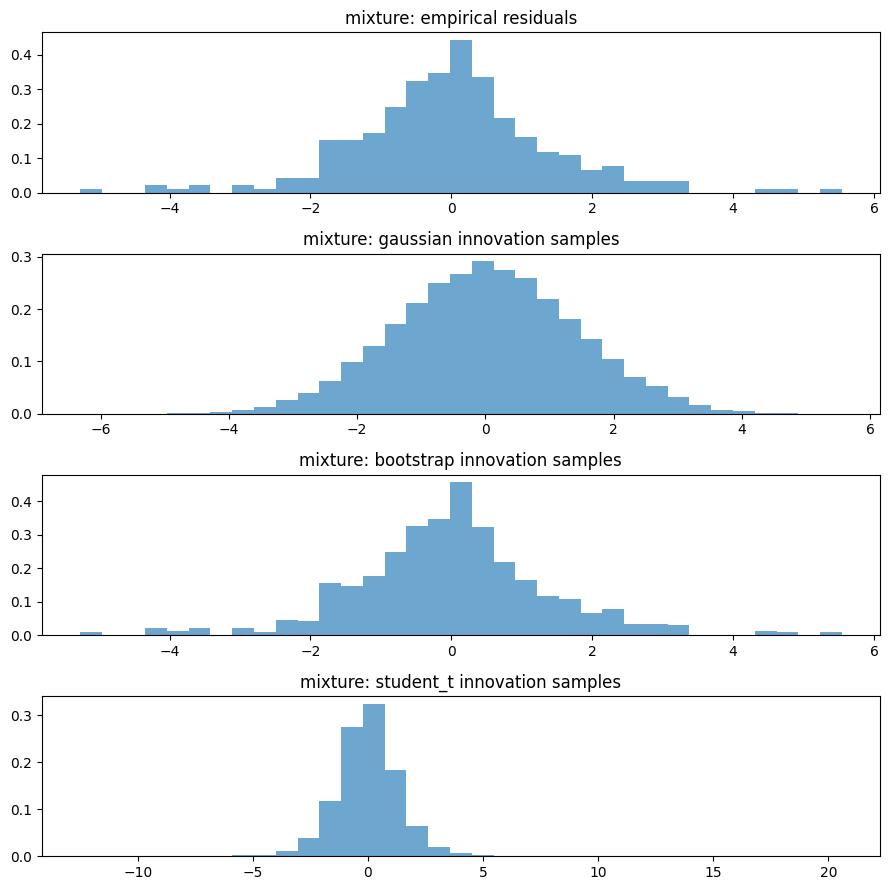

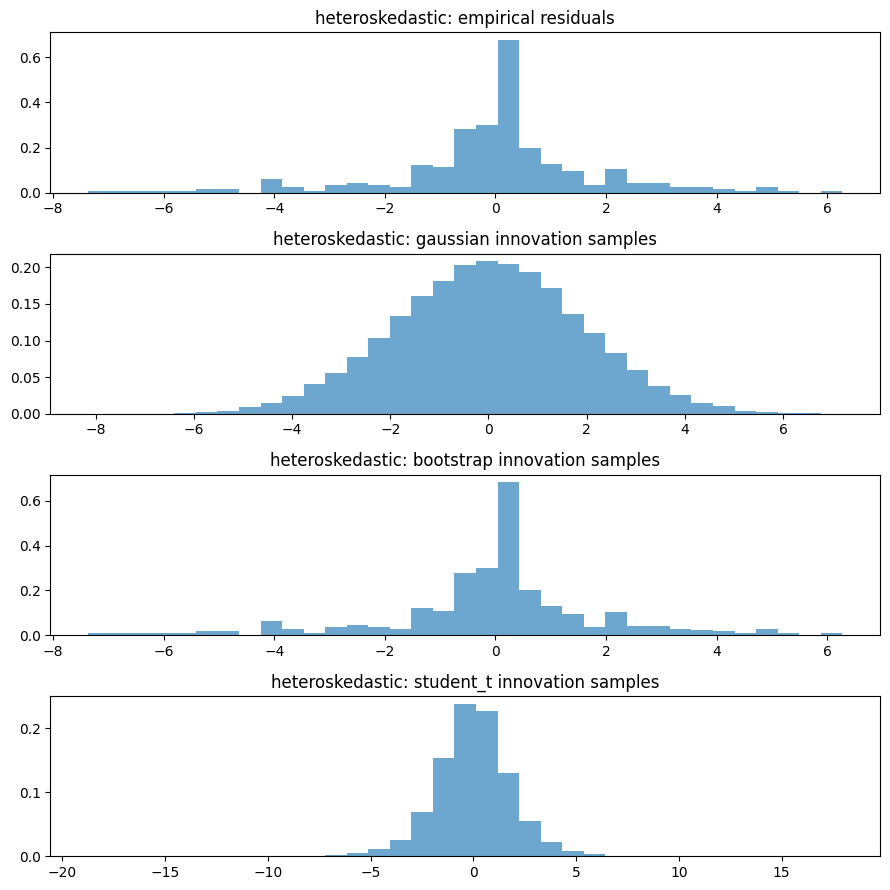

In [9]:
for dgp_name in dgp_names:
    plot_innovation_comparison(
        dgp_name=dgp_name,
        variable=0,
    )

In [10]:
def plot_innovation_qq_comparison(dgp_name, variable=0):
    fig, axes = plt.subplots(
        4,
        1,
        figsize=(7, 12),
    )

    residuals = residual_store[dgp_name][:, variable]

    stats.probplot(
        residuals,
        dist="norm",
        plot=axes[0],
    )
    axes[0].set_title(f"{dgp_name}: empirical residuals QQ")

    for ax, model_name in zip(
        axes[1:],
        ["gaussian", "bootstrap", "student_t"],
    ):
        samples = flatten_sampled_innovations(
            sampled_innovations[dgp_name][model_name]
        )[:, variable]

        stats.probplot(
            samples,
            dist="norm",
            plot=ax,
        )

        ax.set_title(f"{dgp_name}: {model_name} samples QQ")

    plt.tight_layout()
    plt.show()

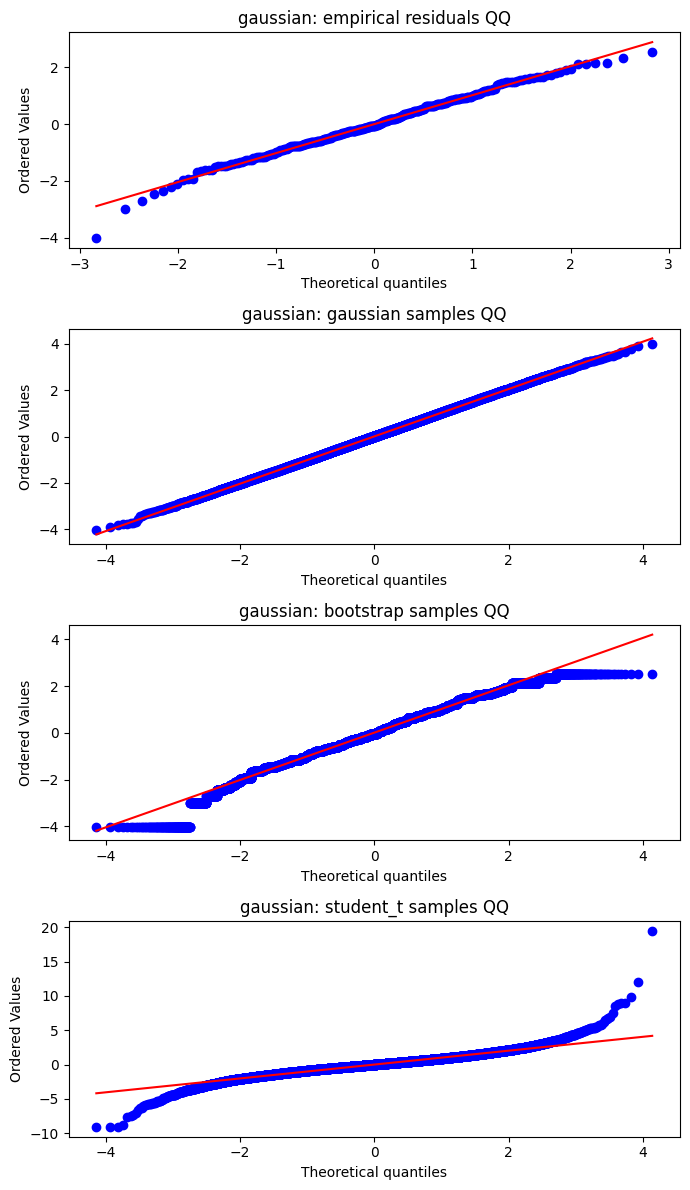

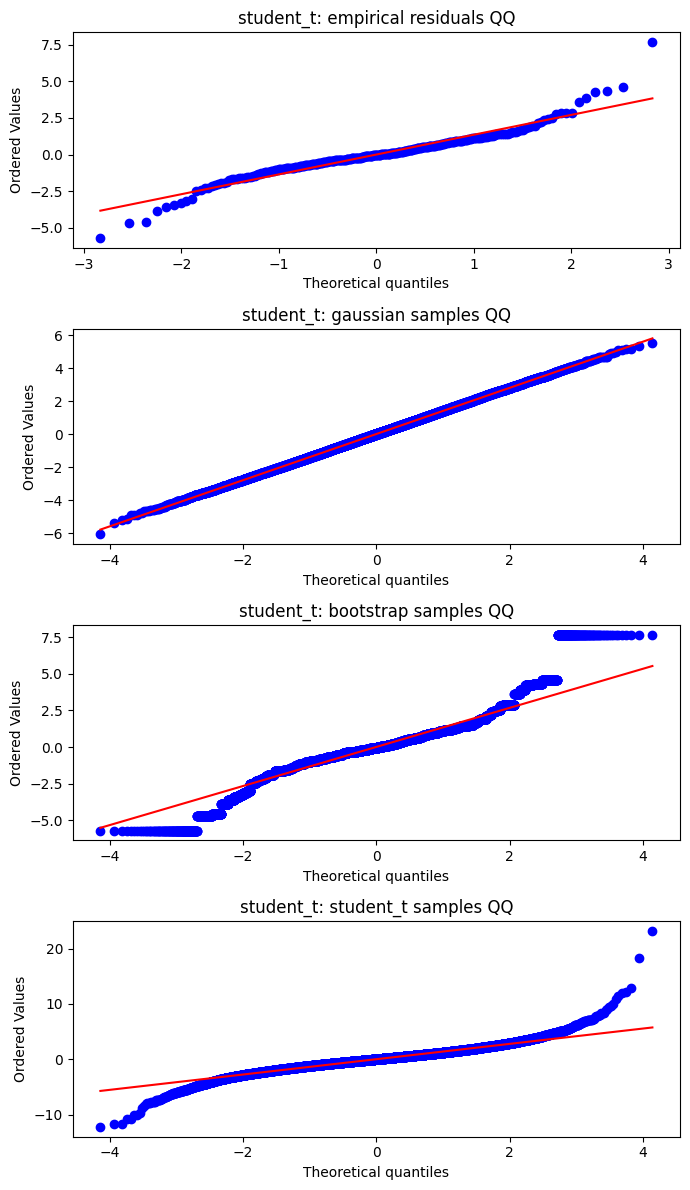

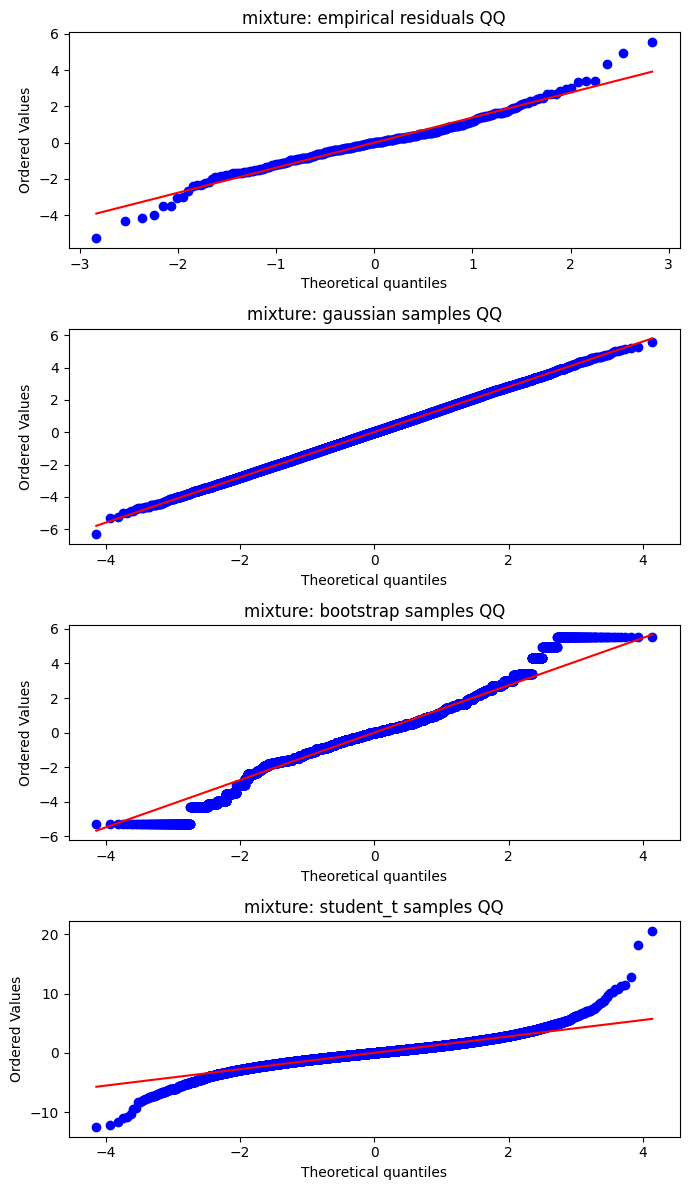

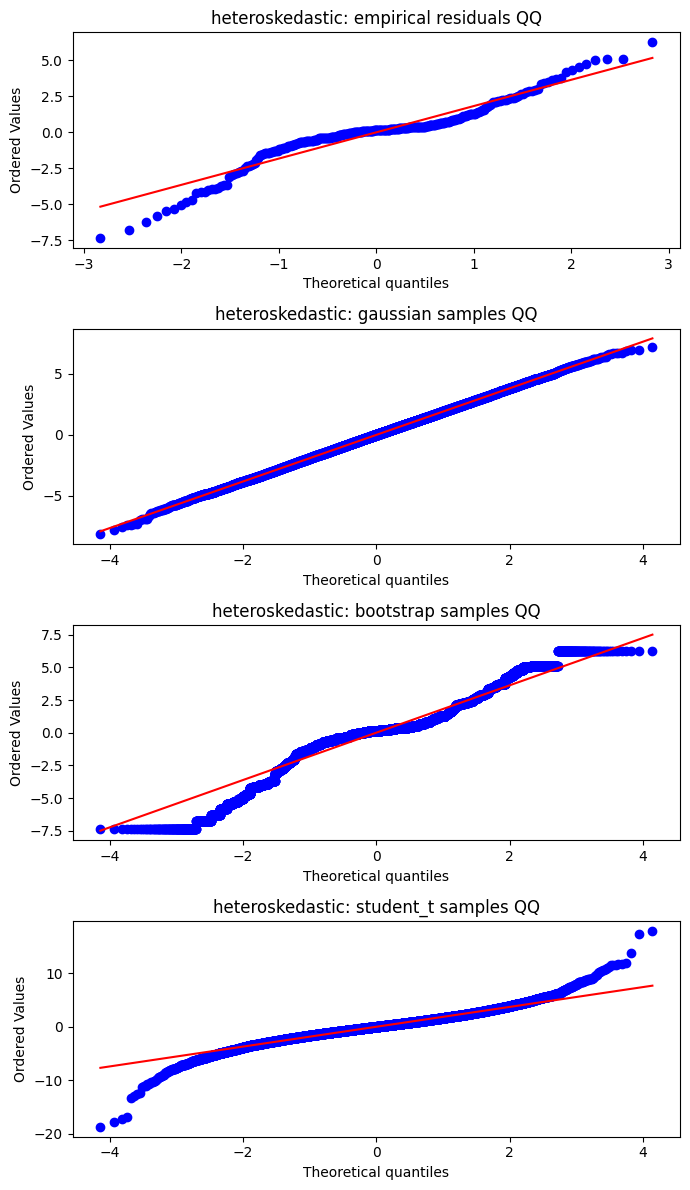

In [11]:
for dgp_name in dgp_names:
    plot_innovation_qq_comparison(
        dgp_name=dgp_name,
        variable=0,
    )

In [12]:
# save output
run_dir = make_run_dir(
    base_dir=ROOT / "logs" / "experiments",
    run_name="04_innovations",
)

metrics = {
    "notebook": "04_innovations",
    "dgp_names": dgp_names,
    "innovation_model_names": innovation_model_names,
    "n_paths": n_paths,
    "horizon": horizon,
    "student_t_df": student_t_df,
    "innovation_samples_saved": True,
    "diagnostics_saved": True,
}

save_metrics_json(
    metrics,
    run_dir / "innovation_config.json",
)

print("Saved logs to:", run_dir)

Saved logs to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/logs/experiments/20260610_152839_04_innovations
